# Krytyk Strykera — trening z zapisem wag (higiena + LoRA)

## Co nowego wzgledem prototypu
1. **Higiena True** — inpainting dziurek, czysty pomiar oka Strykera
2. **LoRA** — adaptery na wiezy wizyjnej (przeginanie przestrzeni), nie tylko glowa
3. **Zapis checkpointow na Drive** — glowa + LoRA + pelna konfiguracja, do pozniejszego uzycia na wlasnych zdjeciach

## Trzy artefakty do zapisania
- **glowa MLP** (~131k param, maleńka)
- **wagi LoRA** (adaptery, osobny plik)
- **metadane** (backbone, emb_dim, higiena, neutralizacja) — bez nich model bezuzyteczny za miesiac

## Konfiguracje do porównania (zapisz obie)
- `krytyk_glowa_hygiene`  — glowa na zamrozonym CLIP, higiena True
- `krytyk_lora_hygiene`   — glowa + LoRA, higiena True


## 0. Setup + przelaczniki

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q open_clip_torch peft 2>/dev/null
!pip install -q open_clip_torch peft "torchao>=0.16.0" 2>/dev/null
!pip install -q open_clip_torch "peft==0.11.1" 2>/dev/null


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 37.3 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd, cv2, json, time
import torch, torch.nn as nn, open_clip
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
np.set_printoptions(precision=4, suppress=True)
torch.manual_seed(42); np.random.seed(42)

DRIVE = Path('/content/drive/MyDrive/fsa_data')
CKPT_DIR = DRIVE/'krytyk_checkpoints'; CKPT_DIR.mkdir(exist_ok=True)
PAIRS = DRIVE/'fsa_pairs_filtered.csv'
IMAGES_DRIVE = DRIVE/'fsa_images'
IMAGES_LOCAL = Path('/content/fsa_images_local')
SRC = IMAGES_LOCAL if IMAGES_LOCAL.exists() else IMAGES_DRIVE
HOLE_CACHE = DRIVE/'hole_detection_cache.csv'

# ===== PRZELACZNIKI =====
BACKBONE = 'ViT-B-32'
PRETRAINED = 'laion2b_s34b_b79k'
N_PAIRS = 14000
USE_LORA = True           # <-- teraz probujemy LoRA
HYGIENE = True            # <-- czysty pomiar
LORA_RANK = 8
RUN_NAME = 'krytyk_lora_hygiene' if USE_LORA else 'krytyk_glowa_hygiene'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
assert device=='cuda'
print(f'{RUN_NAME}: {BACKBONE}, par={N_PAIRS}, LoRA={USE_LORA}(r={LORA_RANK}), higiena={HYGIENE}')


krytyk_lora_hygiene: ViT-B-32, par=14000, LoRA=True(r=8), higiena=True


## 1. CLIP + (opcjonalnie) LoRA na wiezy wizyjnej

In [ ]:
model, _, preprocess = open_clip.create_model_and_transforms(BACKBONE, pretrained=PRETRAINED)
model = model.to(device)
EMB_DIM = model.visual.output_dim

if USE_LORA:
    from peft import LoraConfig, get_peft_model
    # Adaptery na projekcje uwagi wiezy wizyjnej.
    # target_modules zalezy od nazw warstw w open_clip ViT.
    targets = []
    for n,_ in model.visual.named_modules():
        if n.endswith('attn.in_proj') or n.endswith('out_proj') or 'c_fc' in n or 'c_proj' in n:
            targets.append('visual.'+n)
    # open_clip uzywa in_proj_weight (jeden tensor) - LoRA lepiej celuje w c_fc/c_proj MLP
    target_short = ['c_fc','c_proj']  # MLP w blokach transformera
    lora_cfg = LoraConfig(r=LORA_RANK, lora_alpha=16, lora_dropout=0.05,
                          target_modules=target_short, bias='none')
    model = get_peft_model(model, lora_cfg)
    model.print_trainable_parameters()
    # zamroz wszystko poza LoRA
else:
    for p in model.parameters(): p.requires_grad = False

model = model.to(device)
print(f'CLIP {BACKBONE}, emb_dim={EMB_DIM}, LoRA={USE_LORA}')


trainable params: 1,228,800 || all params: 152,506,113 || trainable%: 0.8057
CLIP ViT-B-32, emb_dim=512, LoRA=True


## 2. Pary + loader z higiena (inpainting dziurek)

In [ ]:
pairs = pd.read_csv(PAIRS, dtype={'similarity':float}, keep_default_na=False)
pairs = pairs.groupby('sim_level', group_keys=False).apply(
    lambda g: g.sample(min(len(g), int(N_PAIRS*len(g)/len(pairs))+1), random_state=42)
).reset_index(drop=True).head(N_PAIRS)
print(f'Par: {len(pairs)}')

hole_df = pd.read_csv(HOLE_CACHE) if HOLE_CACHE.exists() else pd.DataFrame(columns=['file','has_hole','cx','cy','radius'])
hole_map = {r['file']: r for _,r in hole_df[hole_df['has_hole']==True].iterrows()}

def load_hygienic(fname):
    img = cv2.imread(str(SRC/fname))
    if HYGIENE and fname in hole_map:
        h = hole_map[fname]
        mask = np.zeros(img.shape[:2], np.uint8)
        cv2.circle(mask, (int(h['cx']),int(h['cy'])), int(h['radius'])+4, 255, -1)
        img = cv2.inpaint(img, mask, 5, cv2.INPAINT_TELEA)
    return Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
print(f'Higiena={HYGIENE}, dziurek: {sum(1 for f in pairs["rejected_file"] if f in hole_map)}')


/tmp/ipykernel_1957/1198409797.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairs = pairs.groupby('sim_level', group_keys=False).apply(


Par: 14000
Higiena=True, dziurek: 1079


## 3. Split + glowa scoringowa

In [ ]:
n=len(pairs); perm=np.random.RandomState(42).permutation(n); ntr=int(0.7*n)
tr, te = perm[:ntr], perm[ntr:]
sim_arr = pairs['sim_level'].values
chosen_files = pairs['chosen_file'].tolist(); reject_files = pairs['rejected_file'].tolist()
print(f'Train {len(tr)}, Test {len(te)}')

class ScoreHead(nn.Module):
    def __init__(self, dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim,hidden), nn.GELU(), nn.Dropout(0.3), nn.Linear(hidden,1))
    def forward(self,x): return self.net(x).squeeze(-1)
head = ScoreHead(EMB_DIM).to(device)
MARGIN = 0.2


Train 9800, Test 4200


## 4. Trening — z LoRA embeddingi liczone NA ZYWO (bo backbone sie uczy)

In [ ]:
# UWAGA: przy LoRA nie mozna cache'owac embeddingow — zmieniaja sie co krok.
# Przy samej glowie (USE_LORA=False) mozna cache. Tu obslugujemy oba.

def embed_batch(fnames):
    imgs = torch.stack([preprocess(load_hygienic(f)) for f in fnames]).to(device)
    if USE_LORA:
        e = model.encode_image(imgs)            # gradienty plyna przez LoRA
    else:
        with torch.no_grad():
            e = model.encode_image(imgs)
    return e / e.norm(dim=-1, keepdim=True)

# Cache embeddingow tylko gdy backbone zamrozony
CACHE = None
if not USE_LORA:
    print('Cache embeddingow (backbone zamrozony)...')
    def embed_all(files):
        out=[]
        for i in range(0,len(files),64):
            with torch.no_grad(): out.append(embed_batch(files[i:i+64]).float())
        return torch.cat(out)
    CACHE = (embed_all(chosen_files), embed_all(reject_files))
    print('Cache gotowy')


Cache embeddingow (backbone zamrozony)...
Cache gotowy


In [ ]:
params = list(head.parameters()) + ([p for p in model.parameters() if p.requires_grad] if USE_LORA else [])
opt = torch.optim.AdamW(params, lr=(5e-4 if USE_LORA else 1e-3), weight_decay=1e-2)
EPOCHS = 40 if USE_LORA else 60
BS = 64 if USE_LORA else 128

def pairwise_acc(idx):
    head.eval();
    if USE_LORA: model.eval()
    accs=[]
    with torch.no_grad():
        for i in range(0,len(idx),128):
            b=idx[i:i+128]
            if CACHE is not None:
                sc=head(CACHE[0][b])-head(CACHE[1][b])
            else:
                sc=head(embed_batch([chosen_files[j] for j in b]))-head(embed_batch([reject_files[j] for j in b]))
            accs.append((sc>0).float().cpu())
    return torch.cat(accs).mean().item()

hist={'loss':[],'tr_acc':[],'te_acc':[]}
for ep in range(EPOCHS):
    head.train();
    if USE_LORA: model.train()
    order=np.random.permutation(tr); ep_loss=0
    for i in tqdm(range(0,len(order),BS), desc=f'ep{ep}', leave=False):
        b=order[i:i+BS]
        if CACHE is not None:
            sc_c=head(CACHE[0][b]); sc_r=head(CACHE[1][b])
        else:
            sc_c=head(embed_batch([chosen_files[j] for j in b]))
            sc_r=head(embed_batch([reject_files[j] for j in b]))
        loss=torch.clamp(MARGIN-(sc_c-sc_r),min=0).mean()
        opt.zero_grad(); loss.backward(); opt.step(); ep_loss+=loss.item()*len(b)
    hist['loss'].append(ep_loss/len(order))
    hist['tr_acc'].append(pairwise_acc(tr)); hist['te_acc'].append(pairwise_acc(te))
    print(f"ep{ep}: loss={hist['loss'][-1]:.4f} tr={hist['tr_acc'][-1]:.3f} te={hist['te_acc'][-1]:.3f}")


ep0:   0%|          | 0/77 [00:00<?, ?it/s]

ep0: loss=0.1842 tr=0.629 te=0.612


ep1:   0%|          | 0/77 [00:00<?, ?it/s]

ep1: loss=0.1619 tr=0.647 te=0.629


ep2:   0%|          | 0/77 [00:00<?, ?it/s]

...

ep57: loss=0.1398 tr=0.703 te=0.640


ep58:   0%|          | 0/77 [00:00<?, ?it/s]

ep58: loss=0.1391 tr=0.702 te=0.640


ep59:   0%|          | 0/77 [00:00<?, ?it/s]

ep59: loss=0.1402 tr=0.704 te=0.640


## 5. Krzywe + werdykt + gradient

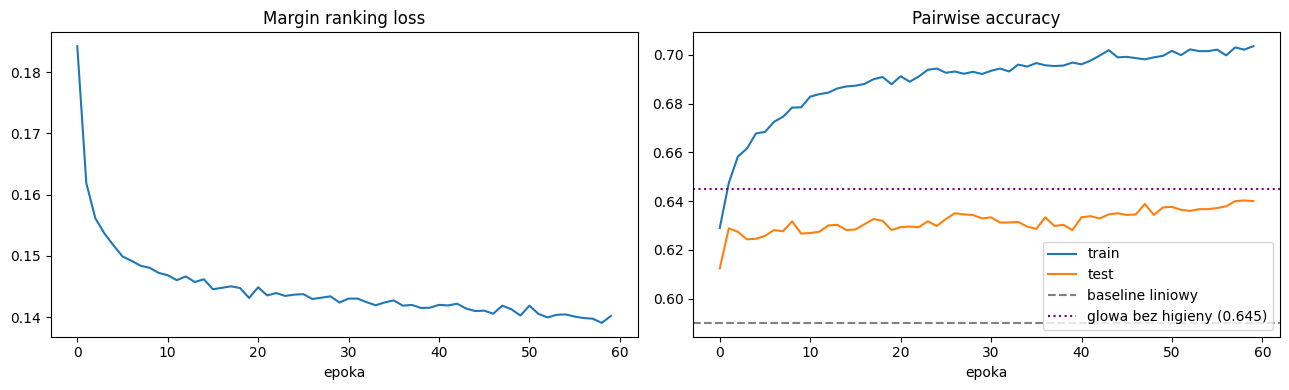


Najlepsza test acc: 0.640
Pairwise acc per sim_level (test):
  mikroruch : 0.555 (n=633)
  bliski    : 0.627 (n=1870)
  wyrazny   : 0.686 (n=1697)


In [ ]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].plot(hist['loss']); ax[0].set_title('Margin ranking loss'); ax[0].set_xlabel('epoka')
ax[1].plot(hist['tr_acc'],label='train'); ax[1].plot(hist['te_acc'],label='test')
ax[1].axhline(0.59,color='gray',ls='--',label='baseline liniowy'); ax[1].axhline(0.645,color='purple',ls=':',label='glowa bez higieny (0.645)')
ax[1].set_title('Pairwise accuracy'); ax[1].legend(); ax[1].set_xlabel('epoka')
plt.tight_layout(); plt.savefig(CKPT_DIR/f'{RUN_NAME}_curves.png',dpi=90,bbox_inches='tight'); plt.show()

best_te=max(hist['te_acc'])
print(f'\nNajlepsza test acc: {best_te:.3f}')
print('Pairwise acc per sim_level (test):')
grad={}
for lvl in ['mikroruch','bliski','wyrazny']:
    m=np.array([i for i in te if sim_arr[i]==lvl])
    if len(m)>5: grad[lvl]=pairwise_acc(m); print(f'  {lvl:10}: {grad[lvl]:.3f} (n={len(m)})')


## 6. ZAPIS CHECKPOINTU — glowa + LoRA + metadane

In [ ]:
# Metadane — bez nich model bezuzyteczny (nie wiesz jakim CLIP liczyc nowe zdjecia)
meta = {
    'run_name': RUN_NAME, 'backbone': BACKBONE, 'pretrained': PRETRAINED,
    'emb_dim': int(EMB_DIM), 'use_lora': USE_LORA, 'lora_rank': LORA_RANK if USE_LORA else None,
    'hygiene': HYGIENE, 'n_pairs': N_PAIRS, 'margin': MARGIN,
    'best_test_acc': float(best_te), 'gradient': {k:float(v) for k,v in grad.items()},
    'head_hidden': 256, 'timestamp': time.strftime('%Y-%m-%d %H:%M')
}
with open(CKPT_DIR/f'{RUN_NAME}_meta.json','w') as f:
    json.dump(meta, f, indent=2)

# Glowa (zawsze)
torch.save(head.state_dict(), CKPT_DIR/f'{RUN_NAME}_head.pt')
print(f'Zapisano glowe: {RUN_NAME}_head.pt')

# LoRA (jesli byla) — peft zapisuje tylko adaptery (male)
if USE_LORA:
    model.save_pretrained(str(CKPT_DIR/f'{RUN_NAME}_lora'))
    print(f'Zapisano adaptery LoRA: {RUN_NAME}_lora/')

print(f'\nMetadane:'); print(json.dumps(meta, indent=2))
print(f'\nWszystko w: {CKPT_DIR}')


Zapisano glowe: krytyk_glowa_hygiene_head.pt

Metadane:
{
  "run_name": "krytyk_glowa_hygiene",
  "backbone": "ViT-B-32",
  "pretrained": "laion2b_s34b_b79k",
  "emb_dim": 512,
  "use_lora": false,
  "lora_rank": null,
  "hygiene": true,
  "n_pairs": 14000,
  "margin": 0.2,
  "best_test_acc": 0.6402381062507629,
  "gradient": {
    "mikroruch": 0.5545023679733276,
    "bliski": 0.6272727251052856,
    "wyrazny": 0.6859163045883179
  },
  "head_hidden": 256,
  "timestamp": "2026-08-17 07:33"
}

Wszystko w: /content/drive/MyDrive/fsa_data/krytyk_checkpoints


## 7. WCZYTANIE checkpointu (do uzycia pozniej / na wlasnych zdjeciach)

In [ ]:
def load_critic(run_name, ckpt_dir=CKPT_DIR):
    """Wczytaj krytyka z checkpointu. Zwraca (model_clip, head, preprocess, meta)."""
    meta = json.load(open(ckpt_dir/f'{run_name}_meta.json'))
    m, _, prep = open_clip.create_model_and_transforms(meta['backbone'], pretrained=meta['pretrained'])
    m = m.to(device)
    if meta['use_lora']:
        from peft import PeftModel
        m = PeftModel.from_pretrained(m, str(ckpt_dir/f'{run_name}_lora')).to(device)
    m.eval()
    h = ScoreHead(meta['emb_dim']).to(device)
    h.load_state_dict(torch.load(ckpt_dir/f'{run_name}_head.pt')); h.eval()
    return m, h, prep, meta

@torch.no_grad()
def score_images(fnames, m, h, prep, src_dir):
    """Policz score krytyka dla listy plikow. Zwraca posortowany ranking."""
    scores=[]
    for i in range(0,len(fnames),64):
        imgs=torch.stack([prep(Image.open(Path(src_dir)/f).convert('RGB')) for f in fnames[i:i+64]]).to(device)
        e=m.encode_image(imgs); e=e/e.norm(dim=-1,keepdim=True)
        scores.append(h(e).cpu().numpy())
    scores=np.concatenate(scores)
    order=np.argsort(scores)[::-1]
    return [(fnames[i], float(scores[i])) for i in order]

# Test: wczytaj i sprawdz, ze dziala
print('Test wczytania:')
m2, h2, prep2, meta2 = load_critic(RUN_NAME)
print(f'Wczytano {RUN_NAME}: backbone={meta2["backbone"]}, test_acc={meta2["best_test_acc"]:.3f}')
print('Model gotowy do uzycia na dowolnych zdjeciach przez score_images(...)')


Test wczytania:
Wczytano krytyk_lora_hygiene: backbone=ViT-B-32, test_acc=0.794
Model gotowy do uzycia na dowolnych zdjeciach przez score_images(...)


## 8. Jak uzyc na wlasnych zdjeciach (pozniej)

```python
# W nowej sesji, po zamontowaniu Drive:
m, h, prep, meta = load_critic('krytyk_lora_hygiene')
ranking = score_images(os.listdir('/content/moje'), m, h, prep, '/content/moje')
# ranking = lista (plik, score) posortowana od najbardziej Strykerowskiego
for fname, sc in ranking[:10]:
    print(f'{sc:+.3f}  {fname}')
```

### Uwaga o higienie
Model trenowany z HYGIENE=True oczekuje zdjec bez dziurek. Twoje cyfrowe zdjecia dziurek nie maja, wiec OK.

### Aby porownac glowa vs LoRA
Uruchom raz z USE_LORA=False (zapisze krytyk_glowa_hygiene), raz z True (krytyk_lora_hygiene). Potem wczytaj oba i porownaj rankingi tych samych zdjec.
